Блок 1 — імпорт бібліотек

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

Блок 2 — автоматичне завантаження датасету

In [2]:
url = "https://raw.githubusercontent.com/anvarnarz/praktikum_datasets/main/museum_visitors.csv"
df = pd.read_csv(url)

print("Перші 5 рядків датасету:")
print(df.head())

Перші 5 рядків датасету:
         Date  Avila Adobe  Firehouse Museum  Chinese American Museum  \
0  2014-01-01        24778              4486                     1581   
1  2014-02-01        18976              4172                     1785   
2  2014-03-01        25231              7082                     3229   
3  2014-04-01        26989              6756                     2129   
4  2014-05-01        36883             10858                     3676   

   America Tropical Interpretive Center  
0                                  6602  
1                                  5029  
2                                  8129  
3                                  2824  
4                                 10694  


Блок 3 — попередній аналіз даних

In [3]:
print("Розмір датасету:", df.shape)

print("\nТипи даних:")
print(df.dtypes)

print("\nКількість пропусків:")
print(df.isna().sum())

Розмір датасету: (59, 5)

Типи даних:
Date                                    object
Avila Adobe                              int64
Firehouse Museum                         int64
Chinese American Museum                  int64
America Tropical Interpretive Center     int64
dtype: object

Кількість пропусків:
Date                                    0
Avila Adobe                             0
Firehouse Museum                        0
Chinese American Museum                 0
America Tropical Interpretive Center    0
dtype: int64


Блок 4 — перевірка на дублікати

In [4]:
print("Кількість дублікатів:", df.duplicated().sum())

df = df.drop_duplicates()

print("Розмір таблиці після видалення дублікатів:", df.shape)

Кількість дублікатів: 0
Розмір таблиці після видалення дублікатів: (59, 5)


Блок 5 — перетворення дати і визначення років

In [5]:
df['Date'] = pd.to_datetime(df['Date'])

years = sorted(df['Date'].dt.year.unique())
print("Датасет містить інформацію за роки:")
print(years)

Датасет містить інформацію за роки:
[np.int32(2014), np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018)]


Блок 6 — перейменування стовпців

In [6]:
df.columns = [col.lower().replace(' ', '_') for col in df.columns]

print("Нові назви стовпців:")
print(df.columns.tolist())

Нові назви стовпців:
['date', 'avila_adobe', 'firehouse_museum', 'chinese_american_museum', 'america_tropical_interpretive_center']


Блок 7 — середня кількість відвідувачів для кожного музею

In [7]:
mean_visitors = df.drop(columns=['date']).mean()

print("Середня кількість відвідувачів для кожного музею:")
print(mean_visitors)

Середня кількість відвідувачів для кожного музею:
avila_adobe                             24061.661017
firehouse_museum                         6472.830508
chinese_american_museum                  2721.254237
america_tropical_interpretive_center     7107.016949
dtype: float64


Блок 8 — мінімум і максимум за 2018 рік

In [8]:
df_2018 = df[df['date'].dt.year == 2018]

print("Мінімальна кількість відвідувачів для кожного музею за 2018 рік:")
print(df_2018.drop(columns=['date']).min())

print("\nМаксимальна кількість відвідувачів для кожного музею за 2018 рік:")
print(df_2018.drop(columns=['date']).max())

Мінімальна кількість відвідувачів для кожного музею за 2018 рік:
avila_adobe                             14718
firehouse_museum                         3306
chinese_american_museum                  2146
america_tropical_interpretive_center     3180
dtype: int64

Максимальна кількість відвідувачів для кожного музею за 2018 рік:
avila_adobe                             25173
firehouse_museum                         8013
chinese_american_museum                  4960
america_tropical_interpretive_center     5837
dtype: int64


Блок 9 — місяці з найбільшою і найменшою загальною кількістю відвідувачів у 2015 році

In [9]:
df_2015 = df[df['date'].dt.year == 2015].copy()

df_2015['total_visitors'] = df_2015.drop(columns=['date']).sum(axis=1)

max_month = df_2015.loc[df_2015['total_visitors'].idxmax(), 'date'].month_name()
min_month = df_2015.loc[df_2015['total_visitors'].idxmin(), 'date'].month_name()

print("Місяць з найбільшою загальною кількістю відвідувачів у 2015 році:", max_month)
print("Місяць з найменшою загальною кількістю відвідувачів у 2015 році:", min_month)

Місяць з найбільшою загальною кількістю відвідувачів у 2015 році: May
Місяць з найменшою загальною кількістю відвідувачів у 2015 році: February


Блок 10 — порівняння Avila Adobe у літні і зимові місяці 2018 року

In [10]:
summer_months = [6, 7, 8]
winter_months = [12, 1, 2]

summer_visitors = df_2018[df_2018['date'].dt.month.isin(summer_months)]['avila_adobe'].sum()
winter_visitors = df_2018[df_2018['date'].dt.month.isin(winter_months)]['avila_adobe'].sum()

print("Кількість відвідувачів Avila Adobe влітку 2018:", summer_visitors)
print("Кількість відвідувачів Avila Adobe взимку 2018:", winter_visitors)

Кількість відвідувачів Avila Adobe влітку 2018: 66122
Кількість відвідувачів Avila Adobe взимку 2018: 30983


Блок 11 — кореляція між датами і відвідуваністю у 2016 році

In [11]:
df_2016 = df[df['date'].dt.year == 2016].copy()
df_2016['date_numeric'] = df_2016['date'].map(pd.Timestamp.toordinal)

correlation_with_date = df_2016.corr(numeric_only=True)['date_numeric'].drop('date_numeric')

print("Кореляція між датою і кількістю відвідувачів у 2016 році:")
print(correlation_with_date)

Кореляція між датою і кількістю відвідувачів у 2016 році:
avila_adobe                             0.060350
firehouse_museum                       -0.201650
chinese_american_museum                -0.415031
america_tropical_interpretive_center   -0.228172
Name: date_numeric, dtype: float64


Блок 12 — лінійний графік Avila Adobe з часом

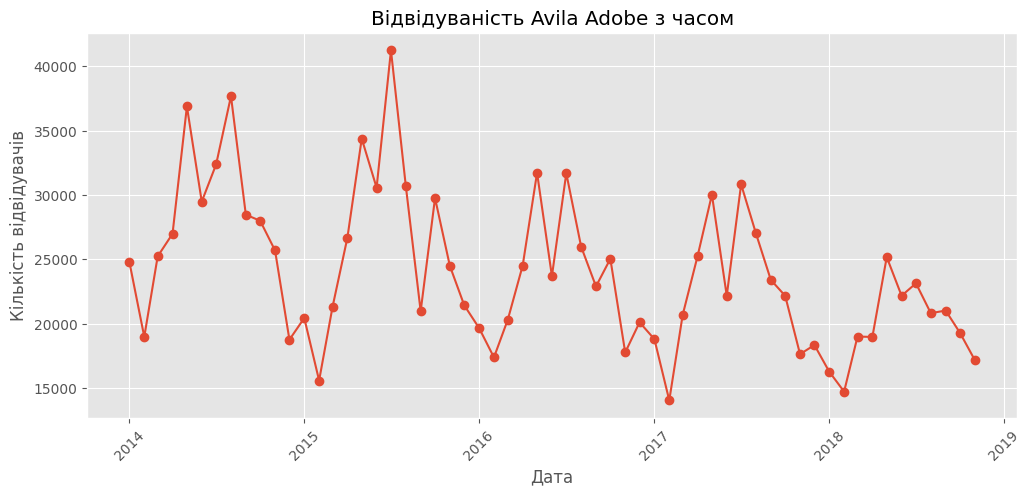

In [12]:
plt.figure(figsize=(12, 5))
plt.plot(df['date'], df['avila_adobe'], marker='o')

plt.title('Відвідуваність Avila Adobe з часом')
plt.xlabel('Дата')
plt.ylabel('Кількість відвідувачів')
plt.xticks(rotation=45)

plt.show()

Блок 13 — boxplot для Chinese American Museum по роках

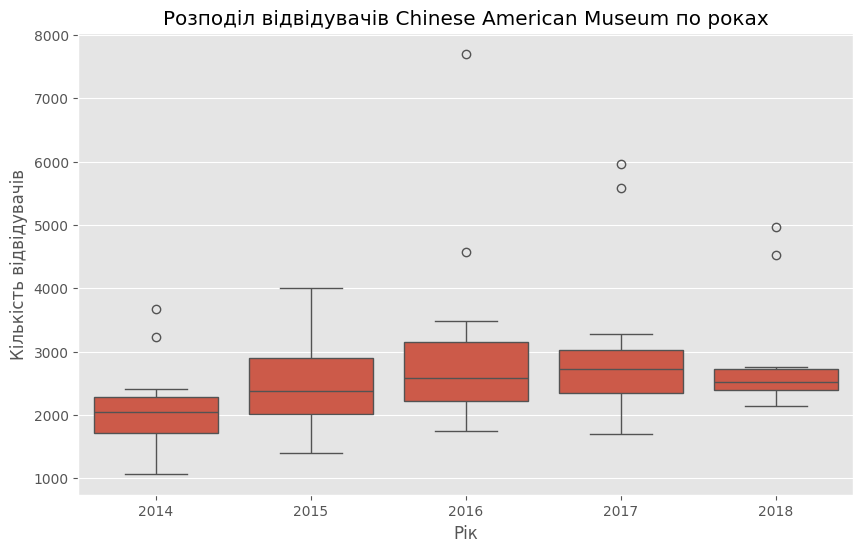

In [13]:
df['year'] = df['date'].dt.year

plt.figure(figsize=(10, 6))
sns.boxplot(x='year', y='chinese_american_museum', data=df)

plt.title('Розподіл відвідувачів Chinese American Museum по роках')
plt.xlabel('Рік')
plt.ylabel('Кількість відвідувачів')

plt.show()

Блок 14 — heatmap кореляції між музеями

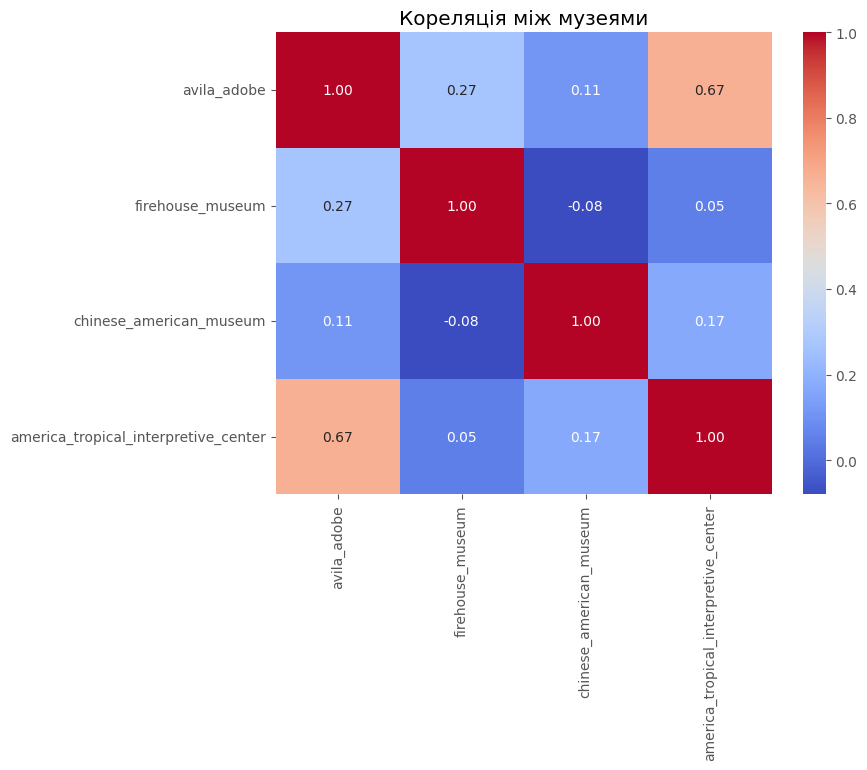

In [14]:
museum_corr = df.drop(columns=['date', 'year']).corr()

plt.figure(figsize=(8, 6))
sns.heatmap(museum_corr, annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Кореляція між музеями')

plt.show()

Блок 15 — histogram для America Tropical Interpretive Center

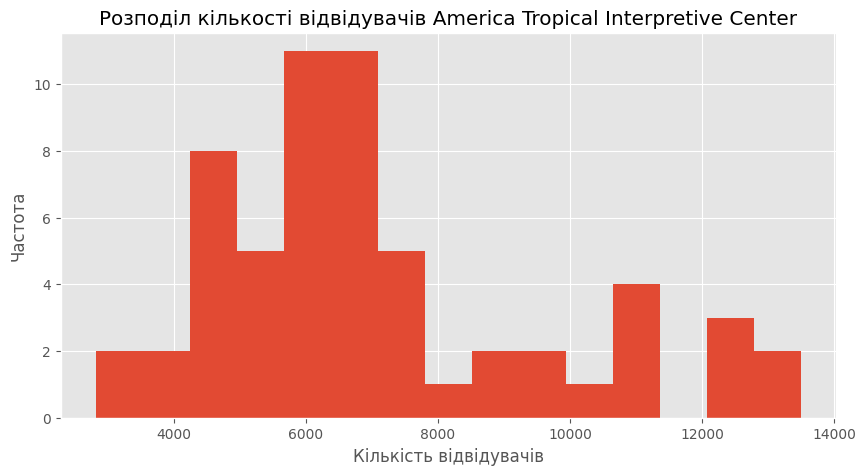

In [15]:
plt.figure(figsize=(10, 5))
plt.hist(df['america_tropical_interpretive_center'], bins=15)

plt.title('Розподіл кількості відвідувачів America Tropical Interpretive Center')
plt.xlabel('Кількість відвідувачів')
plt.ylabel('Частота')

plt.show()

Блок 16 — barplot середньої кількості відвідувачів по музеях

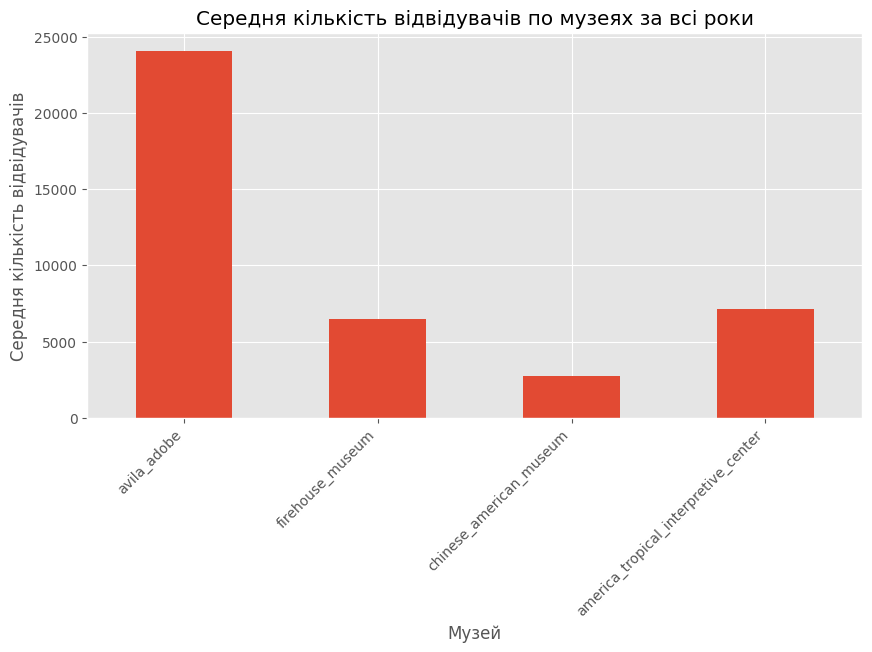

In [16]:
mean_values = df.drop(columns=['date', 'year']).mean()

plt.figure(figsize=(10, 5))
mean_values.plot(kind='bar')

plt.title('Середня кількість відвідувачів по музеях за всі роки')
plt.xlabel('Музей')
plt.ylabel('Середня кількість відвідувачів')
plt.xticks(rotation=45, ha='right')

plt.show()

Блок 17 — висновок

In [17]:
print("""
Висновок

У ході виконання лабораторної роботи було проведено аналіз датасету,
що містить інформацію про відвідуваність музеїв у різні роки.
Було здійснено попередню обробку даних: визначено розмір таблиці,
типи даних, кількість пропусків і перевірено наявність дублікатів.

У процесі аналізу було визначено роки, за які наведено інформацію,
обчислено середню кількість відвідувачів для кожного музею,
знайдено мінімальні та максимальні значення за 2018 рік,
визначено місяці з найбільшою та найменшою загальною кількістю відвідувачів у 2015 році,
а також проведено порівняння сезонної відвідуваності музею Avila Adobe.

Додатково було досліджено кореляцію між датами та показниками відвідуваності у 2016 році.
Для кращого представлення результатів побудовано лінійний графік,
boxplot, heatmap, гістограму та barplot.

Отже, у роботі було закріплено навички обробки, аналізу та візуалізації даних
за допомогою бібліотек pandas, matplotlib і seaborn.
""")


Висновок

У ході виконання лабораторної роботи було проведено аналіз датасету,
що містить інформацію про відвідуваність музеїв у різні роки.
Було здійснено попередню обробку даних: визначено розмір таблиці,
типи даних, кількість пропусків і перевірено наявність дублікатів.

У процесі аналізу було визначено роки, за які наведено інформацію,
обчислено середню кількість відвідувачів для кожного музею,
знайдено мінімальні та максимальні значення за 2018 рік,
визначено місяці з найбільшою та найменшою загальною кількістю відвідувачів у 2015 році,
а також проведено порівняння сезонної відвідуваності музею Avila Adobe.

Додатково було досліджено кореляцію між датами та показниками відвідуваності у 2016 році.
Для кращого представлення результатів побудовано лінійний графік,
boxplot, heatmap, гістограму та barplot.

Отже, у роботі було закріплено навички обробки, аналізу та візуалізації даних
за допомогою бібліотек pandas, matplotlib і seaborn.

